In [2]:
import qcodes

import matplotlib.pyplot as plt
from matplotlib import cm, colors

import numpy as np
import pandas as pd
import time

from scipy.optimize import curve_fit
import pathlib

from pyCircFit_main import *

In [3]:
def circle_fit(freq,re,im,power,plotResults=True):

    # adapted from Kaushal's code to circle fit S21 data 
    amp_array = re+1j*im
    phase = np.unwrap(np.angle(amp_array))

    phase_corr=False
    if phase_corr:
        phase = np.unwrap(np.angle(amp_array))
        line_delay = (phase[0]-phase[-1])/(freq[0]-freq[-1])
        phase_corr_array = -phase[0]-line_delay*(freq-freq[0])
        amp_corr_array = amp_array * np.exp(1j*phase_corr_array)
        q_corr = np.imag(amp_corr_array)
        i_corr = np.real(amp_corr_array)
        mag_corr = np.sqrt(q_corr**2 + i_corr**2)
        phase_correct = np.unwrap(np.angle(amp_corr_array))
        plt.figure(11)
        plt.scatter(freq,10*np.log10(mag_corr))
        plt.figure(22)
        plt.scatter(freq,phase_correct)
        plt.figure(33)
        plt.scatter(i_corr,q_corr)
        plt.gca().set_aspect('equal')
        cresults = circlefit(freq/1e6, i_corr, q_corr,fittype='hanger', plotlabel='test', plot_detail = False, print_results=False, show_plots=False, fitQscl=1, fano = True)
        fit_data = S21_hanger(cresults['a'], cresults['alpha'], 0, cresults['fr'], 
                            cresults['Qtot'], cresults['Qc'], cresults['phi'], freq/1e6)
    
    i_corr = re
    q_corr = im
    cresults = circlefit(freq/1e6, re, im, fittype='hanger', plotlabel='test', plot_detail = False, print_results=False, show_plots=False, fitQscl=1, fano = True)
    fit_data = S21_hanger(cresults['a'], cresults['alpha'], 0, cresults['fr'], 
                            cresults['Qtot'], cresults['Qc'], cresults['phi'], freq/1e6)
        
        # from Kaushal's code to calculate photon number 
    h = 6.63*1e-34
    q = np.abs(cresults['Qtot'])
    q_err = cresults['Qtot_stderr']
    qc = cresults['Qc']
    qc_err = np.abs(cresults['Qc_stderr'])
    qi = cresults['Qi']
    qi_err = np.abs(cresults['Qi_stderr'])
    f = cresults['fr']*1e6
    f_err = cresults['fr_stderr']
    a = cresults['a']

    # plotting results 
    if (plotResults):
        ## from Kaushal's code to plot circle fit
        plt.figure(figsize=(6,6))
        plt.scatter(i_corr, q_corr, label= 'IQ data', s=12)
        plt.plot(np.real(fit_data), np.imag(fit_data), label='IQ fit', linewidth=6, color='C2')
        plt.legend(fontsize=14, loc='upper right')
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel('I (a.u.)', fontsize=12)
        plt.ylabel('Q (a.u.)', fontsize=12)
        plt.title(r'$\bf{f}$'+f' = {np.round(cresults["fr"]*1e-3,4)} GHz' + r'$\pm $' + 
            f'{np.round(cresults['fr_stderr']*1e3,1)} KHz,' + r'$\bf{Q}_i$' + f' = {np.abs(np.round(cresults["Qi"],1))}' + r'$\pm $' + 
            f'{np.round(cresults['Qi_stderr'],1)},'  + r'$\bf{Q}_c$' + f' = {np.abs(np.round(cresults["Qc"],1))}' + r'$\pm $' + 
            f'{np.round(cresults['Qc_stderr'],1)}', fontsize=12)
        plt.gca().set_aspect('equal')
        plt.show()
    
    #returns results for quantities
    return q,q_err,qc,qc_err,qi,qi_err,f,f_err,a

In [5]:
df = pd.read_csv("stemmer_sim_res_6000um_4.155ghz.csv")
df.columns

Index(['Frequency (GHz)', 'RE[S11]', 'IM[S11]', 'RE[S12]', 'IM[S12]',
       'RE[S21]', 'IM[S21]', 'RE[S22]', 'IM[S22]'],
      dtype='object')

In [7]:
re = np.array(df['RE[S12]'])
im = np.array(df['IM[S12]'])
freq = 1e9*np.array(df['Frequency (GHz)'])

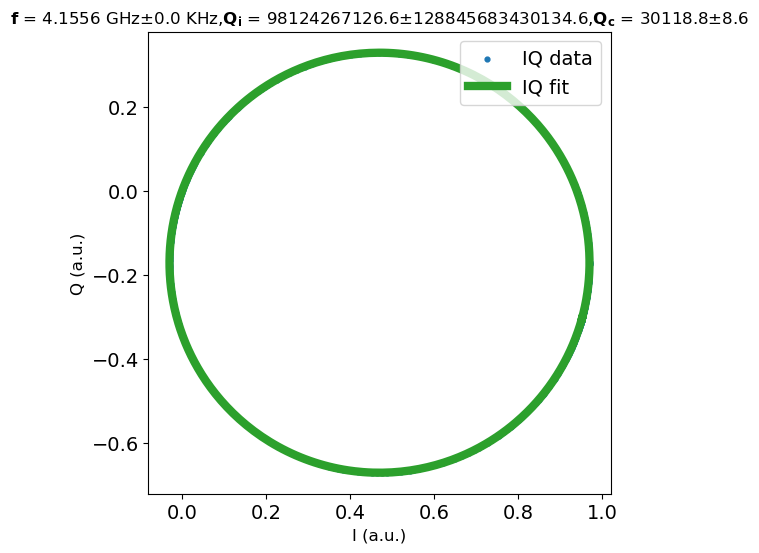

(np.float64(30143.17083392544),
 np.float64(8.584625772564564),
 np.float64(30118.846355163823),
 np.float64(8.602547040066867),
 np.float64(98124267126.57367),
 np.float64(128845683430134.55),
 np.float64(4155580161.8405523),
 np.float64(9.293941444786074e-06),
 np.float64(0.9991654222136019))

In [8]:
circle_fit(freq,re,im,power=-80)

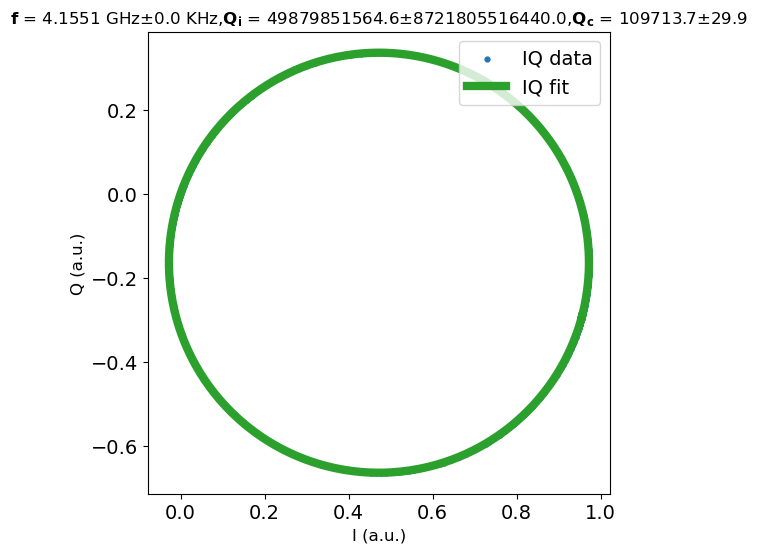

(np.float64(109795.42607260658),
 np.float64(29.84598184998902),
 np.float64(109713.70836444799),
 np.float64(29.892626238797643),
 np.float64(49879851564.63583),
 np.float64(8721805516439.965),
 np.float64(4155079748.265753),
 np.float64(3.7870708465605694e-06),
 np.float64(0.9992227875016975))

In [10]:
df = pd.read_csv("stemmer_sim_res_6000um_4.75ghz_10um_coupling.csv")
re = np.array(df['RE[S12]'])
im = np.array(df['IM[S12]'])
freq = 1e9*np.array(df['Frequency (GHz)'])
circle_fit(freq,re,im,power=-80)

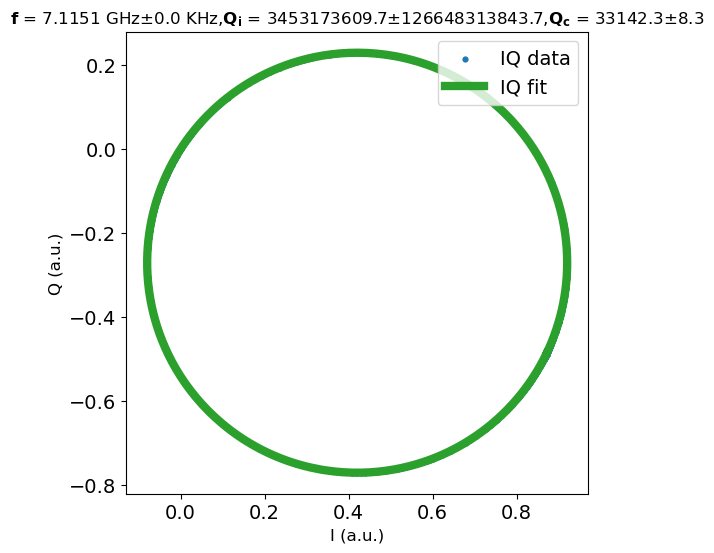

(np.float64(33209.825191073425),
 np.float64(8.253115444042436),
 np.float64(33142.33476834042),
 np.float64(8.292895946255998),
 np.float64(3453173609.6533823),
 np.float64(126648313843.7119),
 np.float64(7115141688.855383),
 np.float64(1.2653048329039137e-05),
 np.float64(0.9977182275111419))

In [5]:
filepath = "stemmer_sim_res_3500um_4.75ghz_10um_coupling.csv"
df = pd.read_csv(filepath)
re = np.array(df['RE[S12]'])
im = np.array(df['IM[S12]'])
freq = 1e9*np.array(df['Frequency (GHz)'])
circle_fit(freq,re,im,power=-80)

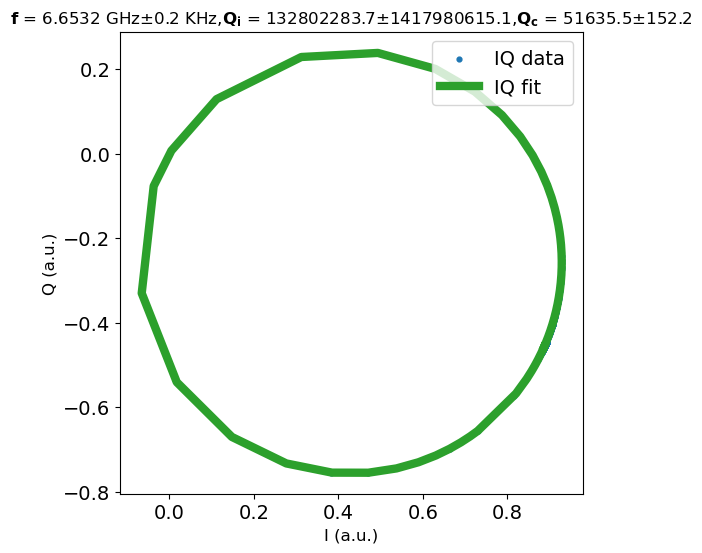

(np.float64(51722.35173062996),
 np.float64(151.8170065379072),
 np.float64(51635.468027971605),
 np.float64(152.16104484510333),
 np.float64(132802283.67944609),
 np.float64(1417980615.137265),
 np.float64(6653245331.062304),
 np.float64(0.00018704572890740643),
 np.float64(0.9979484553492795))

In [4]:
filepath = "lambda2_7500um_7.50ghz_20um_coupling.csv"
df = pd.read_csv(filepath)
re = np.array(df['RE[S12]'])
im = np.array(df['IM[S12]'])
freq = 1e9*np.array(df['Frequency (GHz)'])
circle_fit(freq,re,im,power=-80)